In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.special import hyp2f1

from classy import Class
from multipoles import LegendreMultipoleExtractor
from covariances_pk_xi import PkXiCovariance

%matplotlib inline
%load_ext autoreload
%autoreload 2

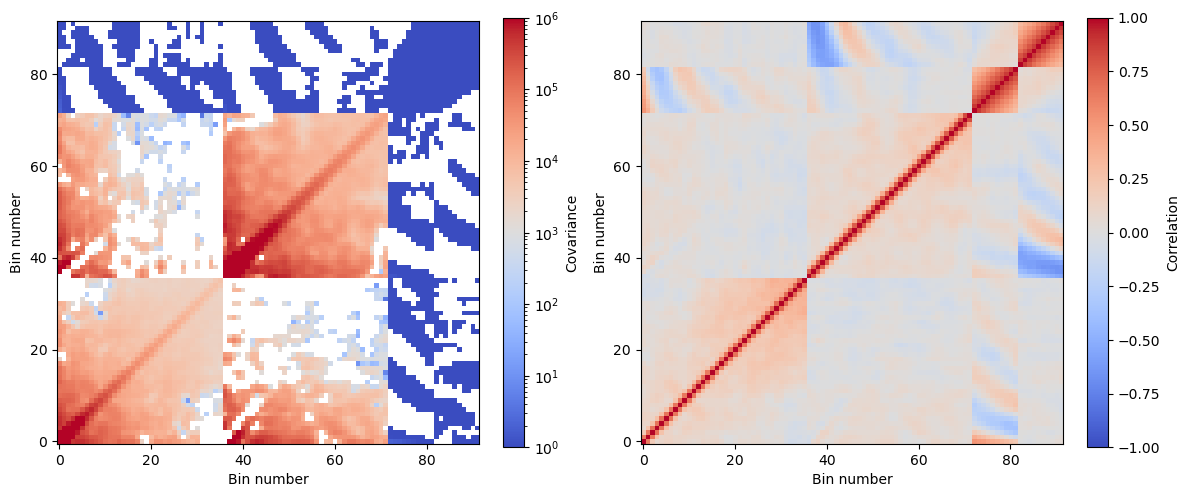

In [2]:
# Path to the data.
db  = '/Users/antonbaleatolizancos/Projects/pre_post_covariance/data/'
# Since it's helpful to have the k values, load
# them from the P(k) file.
fn  = 'Pk_LRG2_desifid.txt'
pkd = np.loadtxt(db+fn)
xid = np.loadtxt(db+'Xi_post_LRG2_desifid.txt')

konh = pkd[:,0]
# Load the covariance matrix.
fn  = 'cov_rsd_BAO_LRG2_desifid.txt'
cov = np.loadtxt(db+fn)
# and compute the correlation matrix.
std  = np.sqrt(np.diag(cov))
corr = (cov/np.outer(std,std)).clip(-1,1)
Nd   = corr.shape[0]
# Work out the boundaries of the sub-blocks.
Np0  = pkd.shape[0]       # Number of P_0 k bins = last index.
Np2  = pkd.shape[0] + Np0 # Last index of P_2 k bins.
Nx0  = xid.shape[0] + Np2           # Last index of xi_0 r bins
Nx2  = xid.shape[0] + Nx0           # Last index of xi_2 r bins

# Get an overview.
fig,ax = plt.subplots(1,2,figsize=(12,12))
#
im1 = ax[0].imshow(cov ,cmap='coolwarm',origin='lower',
                   interpolation='nearest',vmin=1,vmax=1e6,norm='log')
fig.colorbar(im1,label='Covariance',ax=ax[0],fraction=0.046)
#
im2 = ax[1].imshow(corr,cmap='coolwarm',origin='lower',
                   interpolation='nearest',vmin=-1, vmax=1)
fig.colorbar(im2,label='Correlation',ax=ax[1],fraction=0.046)
#
for i in range(ax.size):
    ax[i].set_xlabel('Bin number')
    ax[i].set_ylabel('Bin number')
#
fig.tight_layout()

In [3]:
# We are going to need the linear matter power spectrum.
# We will use CLASS to compute it.

def D_of_a(a,OmegaM=1):
    # From Stephen Chen
    return a * hyp2f1(1./3,1,11./6,-a**3/OmegaM*(1-OmegaM)) / hyp2f1(1./3,1,11./6,-1/OmegaM*(1-OmegaM))

def f_of_a(a, OmegaM=1):
    # From Stephen Chen
    Da = D_of_a(a,OmegaM=OmegaM)
    ret = Da/a - a*(6*a**2 * (1 - OmegaM) * hyp2f1(4./3, 2, 17./6, -a**3 *  (1 - OmegaM)/OmegaM))/(11*OmegaM)/hyp2f1(1./3,1,11./6,-1/OmegaM*(1-OmegaM))
    return a * ret / Da

z = 0.8
pkparams = {
    'output': 'mPk',
    'P_k_max_h/Mpc': 20.,
    'z_pk': '0.0,10',
    'A_s': 2.1e-9,
    'n_s': 0.9649,
    'h': 70 / 100.,
    'N_ur': 2.033,
    'N_ncdm': 1,
    'm_ncdm': 0.06,
    'tau_reio': 0.0568,
    'omega_b': 0.022,
    'omega_cdm': 0.12}

OmegaM = (pkparams['omega_cdm'] + pkparams['omega_b'] + 0.0106 *pkparams['m_ncdm']) / pkparams['h'] ** 2

pkclass = Class()
pkclass.set(pkparams)
pkclass.compute()

# Calculate growth rate
fnu = pkclass.Omega_nu / pkclass.Omega_m()
f = f_of_a(1 / (1. + z), OmegaM=OmegaM) * (1 - 0.6 * fnu)

# Calculate and renormalize power spectrum
plin = np.array([pkclass.pk_cb(k * pkparams['h'], z) * pkparams['h'] ** 3 for k in konh])

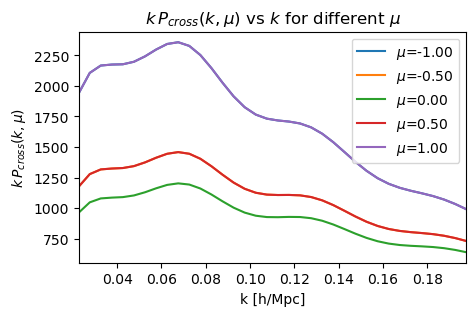

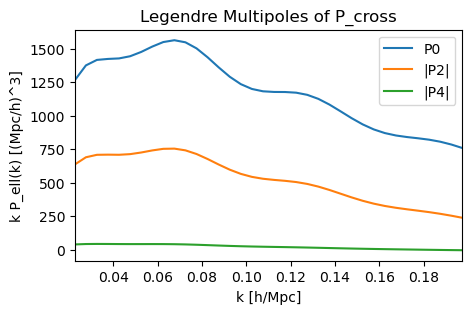

In [4]:
# Now we approximate the P_cross(k, mu) as in the notes. We use a Gaussian smoothing kernel with a width of 15 Mpc/h.

def D_of_mu(mu):
    return 1 + (1+f)**2 * mu**2

def W(k, R_width=15):
    # A fourier-space gaussian smoothing kernel with a real-space width of 15 Mpc/h
    return np.exp(-0.5 * (k * R_width)**2)

def sigma_squared(mu):
    sigmasq_integrand = plin* W(konh)**2 / (6*np.pi**2)  
    return D_of_mu(mu) * np.trapz(sigmasq_integrand, konh)

def P_cross_of_mu(mu, b=1.95):
    return (b+f*mu**2)**2 * plin * np.exp(-konh**2 * sigma_squared(mu) / 2)

plt.figure(figsize=(5, 3))
for i, mu in enumerate(np.linspace(-1, 1, 5)):
    plt.plot(konh, konh*P_cross_of_mu(mu), label=f'$\mu$={mu:.2f}')

plt.xlabel('k [h/Mpc]')
plt.ylabel('$k\,P_{cross}(k, \mu)$')
plt.title('$k\,P_{cross}(k, \mu)$ vs $k$ for different $\mu$')
plt.xlim([konh[0],konh[-1]])
#plt.ylim([-500,500])

plt.legend()
plt.show()

# Compute multipoles of P_cross using Gauss-Legendre quadrature
extractor = LegendreMultipoleExtractor(ngauss=8)
Pcross_ells = extractor.project(P_cross_of_mu, ells=(0, 2, 4))

P0, P2, P4 = Pcross_ells[0], Pcross_ells[2], Pcross_ells[4]

plt.figure(figsize=(5, 3))
plt.plot(konh, konh*P0, label='P0')
plt.plot(konh, konh*P2, label='|P2|')
plt.plot(konh, konh*P4, label='|P4|')
plt.xlabel('k [h/Mpc]')
plt.ylabel('k P_ell(k) [(Mpc/h)^3]')
plt.title('Legendre Multipoles of P_cross')
#plt.ylim([-500,500])
plt.xlim([konh[0],konh[-1]])
plt.legend()


In [ ]:
# Use the Pk–Xi covariance class to compute the disconnected block
V = 8e9  # (Mpc/h)^3
poles = [0, 2]

# Initialize the covariance builder
cov_builder = PkXiCovariance(k=konh, r=xid[:,0], V=V, poles_Pk=poles, poles_Xi=poles,
                             ngauss_leg_product=48, r_avg_nsamp=100)
# Provide the P_cross(k,mu) 
cov_builder.set_Pcross_from_callable(P_cross_of_mu, ells=[0,2,4], ngauss_eval=8)
# Note that we could also have provided the multipoles directly as
#cov_builder.set_Pcross_from_dict(Pcross_ells)

cov_PkXi = cov_builder.compute_covariance()  # shape (3, 3, nk, nr)
print('cov_PkXi shape:', cov_PkXi.shape)

cov_PkXi shape: (2, 2, 36, 10)


/Users/antonbaleatolizancos/Projects/pre_post_covariance/covariances_pk_xi.py:104: ComplexWarning: Casting complex values to real discards the imaginary part
  cov[i, j, :, :] = S_k[:, None] * pref[None, :]


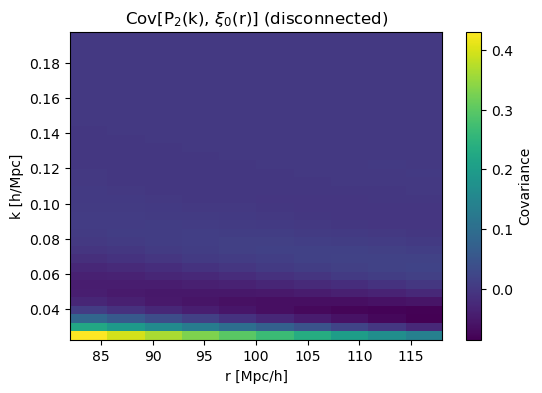

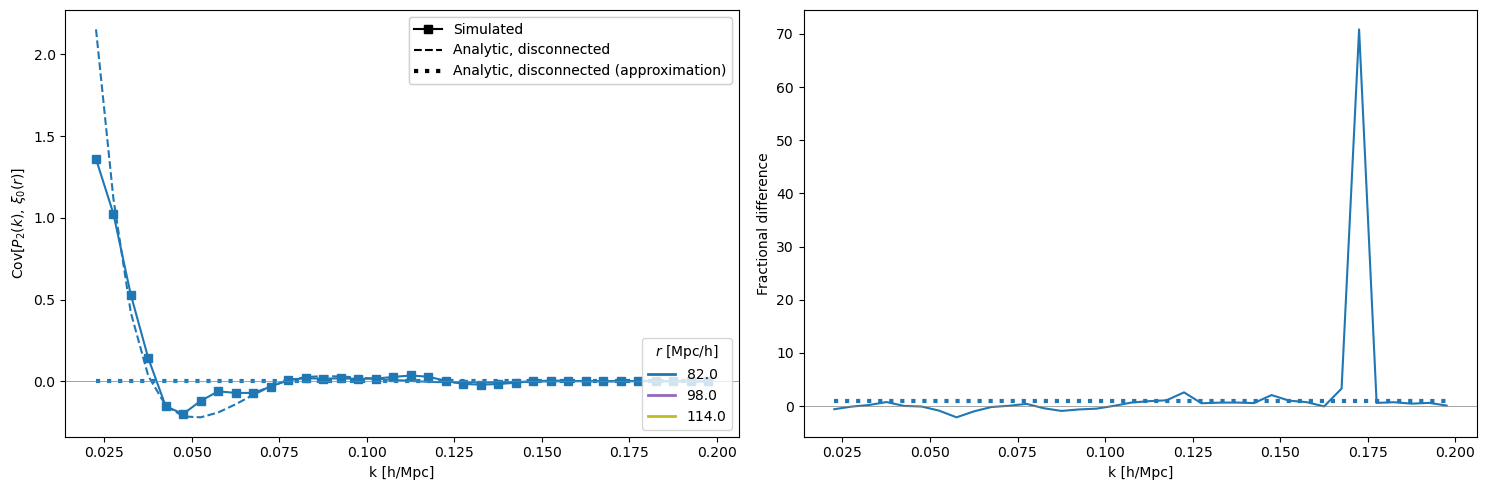

In [14]:
# Visualize a slice
Pkpole = 2
Xipole = 0
adhoc_rescaling = 5

rbins = np.arange(0, 10, 4)

Pkidx = poles.index(Pkpole)
xiidx = poles.index(Xipole)

plt.figure(figsize=(6, 4))
plt.imshow(cov_PkXi[Pkidx, xiidx, :, :], aspect='auto', origin='lower',
           extent=[xid[:,0][0], xid[:,0][-1], konh[0], konh[-1]])
plt.xlabel('r [Mpc/h]')
plt.ylabel('k [h/Mpc]')
plt.colorbar(label='Covariance')
plt.title(rf'Cov[P$_{{{Pkpole}}}$(k), $\xi_{{{Xipole}}}$(r)] (disconnected)')
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

for rbin in rbins[:1]:
    cvec = cov[(Pkidx*Np0):(Pkidx+1)*Np0, rbin+Np0*len(cov_builder.poles_Xi)+xid.shape[0]*xiidx]
    theory = adhoc_rescaling * cov_PkXi[Pkidx, xiidx, :, rbin]

    # In a couple cases, we show the approximation that the monopole dominates.
    if (Pkpole == 0 and Xipole == 0):
        pref = 2
    elif (Pkpole == 2 and Xipole == 2):
        pref = -10
    else:
        pref = 0
    th_simp = pref * adhoc_rescaling * (1/V)*(cov_builder._jmean_kr(Xipole)*Pcross_ells[0][:,None]**2)[:,rbin]

    ax[0].plot(konh, cvec, 's-', color='C'+str(rbin), label='Simulated')
    ax[0].plot(konh, theory, color='C'+str(rbin), ls='--', label='Analytic, disconnected')
    ax[0].plot(konh, th_simp, color='C'+str(rbin), ls=':', lw=3, label='Analytic, disconnected, simplified')

    # Residuals
    ax[1].plot(konh, (cvec-theory)/cvec, color='C'+str(rbin))
    ax[1].plot(konh, (cvec-th_simp)/cvec, color='C'+str(rbin), ls=':', lw=3)

    # Add legend for rbins entries with matching colors
    legend_elements = [
        Line2D([0], [0], color='C'+str(rbin), lw=2, label=f'{cov_builder.r[rbin]:.1f}')
        for rbin in rbins
    ]
    line_legend = [
        Line2D([0], [0], color='k', marker='s', linestyle='-', label='Simulated'),
        Line2D([0], [0], color='k', linestyle='--', label='Analytic, disconnected'),
        Line2D([0], [0], color='k', linestyle=':', lw=3, label='Analytic, disconnected (approximation)')
    ]
    # Add legends separately
    # Add both legends without overwriting
    leg1 = ax[0].legend(handles=legend_elements, title=r'$r$ [Mpc/h]', loc='lower right')
    leg2 = ax[0].legend(handles=line_legend,  loc='upper right')
    ax[0].add_artist(leg1)
    # To show both legends, use this workaround:
    ax[0].add_artist(ax[0].get_legend())
ax[0].set_ylabel(rf'$\mathrm{{Cov}}[P_{{{Pkpole}}}(k),\,\xi_{{{Xipole}}}(r)]$')
ax[0].set_xscale('linear')
ax[0].set_xlabel('k [h/Mpc]')

ax[1].set_ylabel('Fractional difference')
ax[1].set_xscale('linear')
ax[1].set_xlabel('k [h/Mpc]')
    
[ax[i].axhline(0, color='gray', ls='-', lw=0.5) for i in range(2)]


fig.tight_layout()